In [ ]:
import pandas as pd
import joblib
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             average_precision_score, confusion_matrix, roc_auc_score)
# Load my new pre-split data which now includes clinical features
data = joblib.load('../Results/split_data.joblib')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
print("Enriched training and testing data loaded successfully.")
print(f"Number of features: {X_train.shape[1]}")


Enriched training and testing data loaded successfully.
Number of features: 113


In [ ]:
# Initialize the XGBoost Classifier
xgb_model_enriched = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42)
# Train the model on the full enriched training data
print("Training the enriched XGBoost model...")
xgb_model_enriched.fit(X_train, y_train)
print ("Model Training Complete.")


Training the enriched XGBoost model...
Model Training Complete.


--- Classification Report (Enriched XGBoost Model) ---
              precision    recall  f1-score   support

           0       0.65      0.70      0.67        50
           1       0.50      0.44      0.47        34

    accuracy                           0.60        84
   macro avg       0.57      0.57      0.57        84
weighted avg       0.59      0.60      0.59        84


--- Confusion Matrix (Enriched XGBoost Model) ---
                Predicted: 0 | Predicted: 1
Actual: 0      35            | 15           
Actual: 1      19            | 15           

Previous Best ROC AUC Score: 0.5700
Enriched XGBoost ROC AUC Score: 0.5706

Plotting ROC Curve...


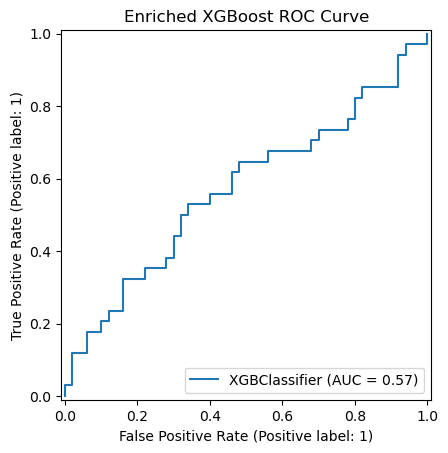

In [ ]:
# Making predictions on the test set
y_pred = xgb_model_enriched.predict(X_test)
y_pred_proba = xgb_model_enriched.predict_proba(X_test)[:, 1]

# --- Evaluation ---
print("--- Classification Report (Enriched XGBoost Model) ---")

print(classification_report(y_test, y_pred))

print("\n--- Confusion Matrix (Enriched XGBoost Model) ---")

cm = confusion_matrix(y_test, y_pred)
print("                Predicted: 0 | Predicted: 1")
print(f"Actual: 0      {cm[0,0]:<13} | {cm[0,1]:<13}")
print(f"Actual: 1      {cm[1,0]:<13} | {cm[1,1]:<13}")

roc_auc_xgb_enriched = roc_auc_score(y_test, y_pred_proba)

print(f"\nPrevious Best ROC AUC Score: 0.5700")
print(f"Enriched XGBoost ROC AUC Score: {roc_auc_xgb_enriched:.4f}")

# Prepare arrays (use variables from the notebook)
y_true = np.asarray(y_test)
y_score = np.asarray(y_pred_proba)
y_pred_labels = np.asarray(y_pred)

# ROC
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_true, y_score)
avg_prec = average_precision_score(y_true, y_score)

# Confusion matrix (absolute + normalized by true class)
cm = confusion_matrix(y_true, y_pred_labels)
cm_norm = cm.astype(float) / (cm.sum(axis=1)[:, None] + 1e-12)

# Build 1x3 Plotly figure: ROC | PR | Confusion Matrix
fig = make_subplots(rows=1, cols=3,
                    subplot_titles=("ROC Curve", "Precision–Recall", "Confusion Matrix"),
                    specs=[[{"type": "xy"}, {"type": "xy"}, {"type": "heatmap"}]],
                    horizontal_spacing=0.08)

# ROC
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines',
                         name=f'ROC (AUC={roc_auc:.3f})',
                         line=dict(color='#636EFA', width=3)),
              row=1, col=1)
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines',
                         line=dict(dash='dash', color='lightgray'),
                         showlegend=False),
              row=1, col=1)
fig.update_xaxes(title_text='False Positive Rate', row=1, col=1)
fig.update_yaxes(title_text='True Positive Rate', row=1, col=1)

# Precision-Recall
fig.add_trace(go.Scatter(x=recall, y=precision, mode='lines',
                         name=f'PR (AP={avg_prec:.3f})',
                         line=dict(color='#00CC96', width=3)),
              row=1, col=2)
fig.update_xaxes(title_text='Recall', row=1, col=2)
fig.update_yaxes(title_text='Precision', row=1, col=2)

# Confusion matrix heatmap (show counts and normalized color)
annot = [[str(int(cm[i, j])) for j in range(cm.shape[1])] for i in range(cm.shape[0])]
fig.add_trace(go.Heatmap(z=cm_norm,
                         x=['Pred:0', 'Pred:1'],
                         y=['True:0', 'True:1'],
                         text=annot,
                         hovertemplate='True: %{y}<br>Pred: %{x}<br>Count: %{text}<br>Proportion: %{z:.3f}<extra></extra>',
                         colorscale='Blues',
                         colorbar=dict(title='Proportion')),
              row=1, col=3)
fig.update_xaxes(title_text='Predicted label', row=1, col=3)
fig.update_yaxes(title_text='True label', row=1, col=3)

# Layout (modern, clean)
fig.update_layout(template='plotly_white',
                  paper_bgcolor='white',
                  plot_bgcolor='white',
                  width=1200, height=420,
                  title_text='Enriched XGBoost — ROC / PR / Confusion Matrix',
                  legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
                  margin=dict(l=40, r=20, t=80, b=40),
                  font=dict(family="Arial", size=12))

fig.update_xaxes(showgrid=True, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridcolor='lightgray')

fig.show()